In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from itertools import combinations

from utils.utils import (
    PYMOO_OK,
    RandomForestDiscovery,
    ScenarioDiscoveryOptimizer,
    TrajectoryAggregator,
    VulnerabilityAnalyzer,
)


In [2]:
# Enable automatic reloading of modules before executing cells
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(SCRIPT_DIR)
ML_DIR = os.path.join(PARENT_DIR, "ml_scripts")
DATA_DIR = os.path.join(ML_DIR, "output")
ENSEMBLE_DATA_DIR = os.path.join(DATA_DIR, "ensemble")
POST_PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "2030_emissions")

In [4]:
# Load the data
run_id = 1773188058
iso_alpha_3 = "CAN"
df = pd.read_parquet(os.path.join(POST_PROCESSED_DATA_DIR, f"post_processed_projected_emissions_{run_id}.parquet"))
df.head()


,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [5]:
# Filter the data for the specific country
df = df[df["iso_alpha_3"] == iso_alpha_3]

### Class-Based Version
This notebook mirrors `scenario_discovery_simple.ipynb` but delegates core logic to classes in `scenario_discovery.utils`.

### Compute Vulnerability Indicator

In [6]:
# First compute percentage difference between final year and 2022.

df_pivot = VulnerabilityAnalyzer.compute_emissions_change(
    df,
    "2022",
    "2030",
    "con_edgar_ghg_mt_hp_trend",
)
df_pivot.head()


,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
0,id_CAN_1,CAN,741.318311,765.335776,1
1,id_CAN_10,CAN,741.318311,696.851524,0
2,id_CAN_100,CAN,741.318311,673.898552,0
3,id_CAN_1000,CAN,741.318311,759.870655,1
4,id_CAN_101,CAN,741.318311,754.569189,1


/Users/tony/Documents/research_project/etpe_project/scenario_discovery/utils/utils.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=vuln_col, data=df, palette=palette, order=order, ax=ax_local)


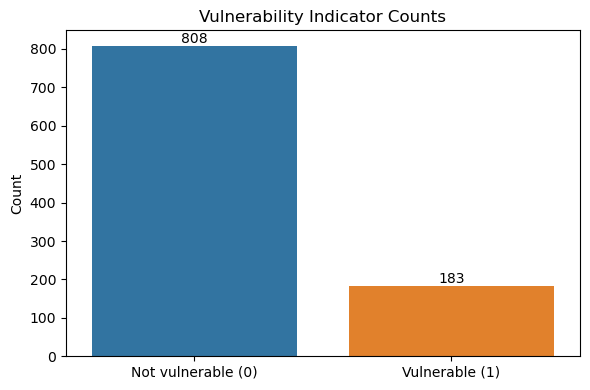

In [7]:
ax = VulnerabilityAnalyzer.plot_vulnerability_counts(df_pivot)


### Aggregate ARIMA data

In [8]:
# Load the projected data
ensemble_df = pd.read_parquet(os.path.join(ENSEMBLE_DATA_DIR, f"ensemble_arima_{run_id}.parquet"))
ensemble_df.head()

,iso_alpha_3,future_id,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,...,cap_govt_effectiveness,con_ndgain_score,emissions_anchor_2022,years_since_2022,trend_year_interaction,em_lag_1y,em_trend_3y,em_trend_5y,em_volatility_5y,em_acceleration
0,AFG,id_AFG_1,2022,3.405119,0.048790,0.0,0.0,5.880000,0.040182,0.0,...,-1.880035,32.633596,NaN,0.0,NaN,3.399653,-0.022348,-0.028681,0.050438,0.006334
1,AFG,id_AFG_1,2023,3.406011,0.055667,0.0,0.0,6.009763,0.000000,0.0,...,-2.028122,32.452377,NaN,1.0,NaN,3.400199,-0.018481,-0.027746,0.049581,0.006627
2,AFG,id_AFG_1,2024,3.395691,0.063294,0.0,0.0,6.157955,0.000000,0.0,...,-2.189786,33.519214,NaN,2.0,NaN,3.400289,-0.019795,-0.026254,0.047960,0.006346
3,AFG,id_AFG_1,2025,3.384084,0.070110,0.0,0.0,6.515455,0.000000,0.0,...,-2.319343,33.014896,NaN,3.0,NaN,3.399257,-0.020584,-0.025285,0.046763,0.006171
4,AFG,id_AFG_1,2026,3.391456,0.071661,0.0,0.0,6.538660,0.000000,0.0,...,-2.482714,34.419108,NaN,4.0,NaN,3.398096,-0.021209,-0.026219,0.046283,0.006201


In [9]:
ensemble_df.columns

Index(['iso_alpha_3', 'future_id', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'x_log_signed_inc_carbon_pricing_coverage',
       'con_forest_area_pct', 'con_agricultural_land_pct',
       'x_log_signed_con_nuclear', 'x_log_signed_con_electricity_access_pct',
       'inc_has_framework_law', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score',
       'emissions_anchor_2022', 'years_s

In [10]:
# Aggregate ensemble data so we only get a single row per future_id

# First we remove all emisssion-related variables to avoid any sort of leakage
emission_cols = [
    'x_log_signed_con_edgar_ghg_mt',
    'emissions_anchor_2022',
    'years_since_2022',
    'trend_year_interaction',
    'em_lag_1y',
    'em_trend_3y',
    'em_trend_5y',
    'em_volatility_5y',
    'em_acceleration'
]

ensemble_df = ensemble_df.drop(columns=emission_cols, errors='ignore')
ensemble_df = ensemble_df[ensemble_df["iso_alpha_3"] == iso_alpha_3]

rules_path = os.path.join(ML_DIR, 'config', 'variable_projection_rules.json')
trajectory_aggregator = TrajectoryAggregator(rules_path)
ensemble_agg_df = trajectory_aggregator.aggregate(ensemble_df)
ensemble_agg_df.head()


,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,cap_govt_effectiveness__last,cap_govt_effectiveness__delta,cap_govt_effectiveness__slope,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope
0,id_CAN_1,CAN,2022,2030,9,2.047022,0.261486,1.797418,2.500366,2.500366,...,1.386332,-0.180285,-0.026017,67.628423,0.690537,66.425532,68.499936,66.425532,-2.074404,-0.239561
1,id_CAN_10,CAN,2022,2030,9,2.330607,0.288716,1.862529,2.692904,2.692904,...,1.361012,-0.205606,-0.023206,67.596413,0.648923,66.448592,68.499936,66.448592,-2.051344,-0.225405
2,id_CAN_100,CAN,2022,2030,9,1.938654,0.046590,1.862529,2.002937,1.954661,...,1.277876,-0.288742,-0.028587,67.793681,0.491410,67.022374,68.499936,67.022374,-1.477561,-0.171110
3,id_CAN_1000,CAN,2022,2030,9,2.343032,0.407372,1.862529,2.955009,2.955009,...,1.409599,-0.157018,-0.012913,67.752661,0.689559,66.784469,68.535428,66.959962,-1.539974,-0.238387
4,id_CAN_101,CAN,2022,2030,9,2.147603,0.282610,1.817817,2.589001,2.589001,...,1.439230,-0.127388,-0.014539,67.690199,0.416082,67.248590,68.499936,67.361786,-1.138150,-0.129732


In [11]:
ensemble_agg_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'cap_govt_effectiveness__last', 'cap_govt_effectiveness__delta',
       'cap_govt_effectiveness__slope', 'con_ndgain_score__mean',
       'con_ndgain_score__std', 'con_ndgain_score__min',
       'con_ndgain_score__max', 'con_ndgain_score__last',
       'con_ndgain_score__delta', 'con_ndgain_score__slope'],
      dtype='object', length=177)

In [12]:
df_pivot.head()

,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
0,id_CAN_1,CAN,741.318311,765.335776,1
1,id_CAN_10,CAN,741.318311,696.851524,0
2,id_CAN_100,CAN,741.318311,673.898552,0
3,id_CAN_1000,CAN,741.318311,759.870655,1
4,id_CAN_101,CAN,741.318311,754.569189,1


In [13]:
merged_df = VulnerabilityAnalyzer.merge_ensemble_with_vulnerability(
    ensemble_agg_df,
    df_pivot,
    on_cols=["future_id", "iso_alpha_3"],
)
merged_df.head()


,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope,2022,2030,vulnerability_indicator
0,id_CAN_1,CAN,2022,2030,9,2.047022,0.261486,1.797418,2.500366,2.500366,...,67.628423,0.690537,66.425532,68.499936,66.425532,-2.074404,-0.239561,741.318311,765.335776,1
1,id_CAN_10,CAN,2022,2030,9,2.330607,0.288716,1.862529,2.692904,2.692904,...,67.596413,0.648923,66.448592,68.499936,66.448592,-2.051344,-0.225405,741.318311,696.851524,0
2,id_CAN_100,CAN,2022,2030,9,1.938654,0.046590,1.862529,2.002937,1.954661,...,67.793681,0.491410,67.022374,68.499936,67.022374,-1.477561,-0.171110,741.318311,673.898552,0
3,id_CAN_1000,CAN,2022,2030,9,2.343032,0.407372,1.862529,2.955009,2.955009,...,67.752661,0.689559,66.784469,68.535428,66.959962,-1.539974,-0.238387,741.318311,759.870655,1
4,id_CAN_101,CAN,2022,2030,9,2.147603,0.282610,1.817817,2.589001,2.589001,...,67.690199,0.416082,67.248590,68.499936,67.361786,-1.138150,-0.129732,741.318311,754.569189,1


In [14]:
merged_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'con_ndgain_score__mean', 'con_ndgain_score__std',
       'con_ndgain_score__min', 'con_ndgain_score__max',
       'con_ndgain_score__last', 'con_ndgain_score__delta',
       'con_ndgain_score__slope', '2022', '2030', 'vulnerability_indicator'],
      dtype='object', length=180)

### Train ML Model

In [15]:
# Then we train the random forest to predict the vulnerability indicator
# and compute feature importance.

non_modeling_cols = [
    "future_id",
    "iso_alpha_3",
    "year_start",
    "year_end",
    "n_years",
    "2022",
    "2030",
]

target_col = "vulnerability_indicator"
rf_discovery = RandomForestDiscovery(test_size=0.2, random_state=42)
rf_result = rf_discovery.fit(
    merged_df,
    target_col=target_col,
    non_modeling_cols=non_modeling_cols,
)

rf_models = rf_result.rf_models
rf_training_summary_df = rf_result.training_summary
feature_importance_df = rf_result.feature_importance

rf_training_summary_df


,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,991,792,199,808,183,trained,172,0.81407,0.879397,0.779947,0.69697,0.621622,0.657143,0.952619,0.005814,0.002369,0.128778


/Users/tony/Documents/research_project/etpe_project/scenario_discovery/utils/utils.py:398: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=top_features_df, palette="viridis")


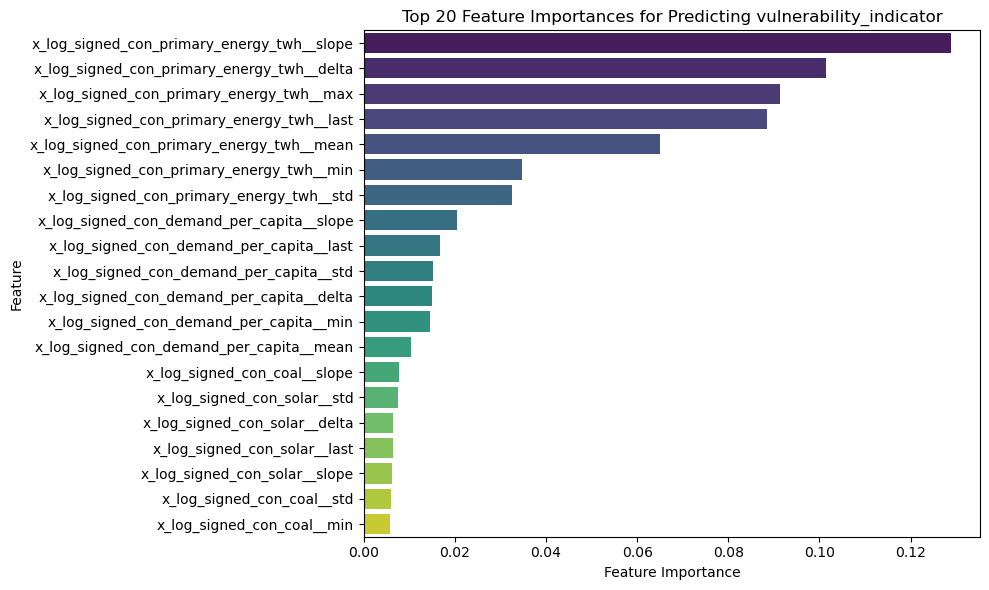

,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,991,792,199,808,183,trained,172,0.81407,0.879397,0.779947,0.69697,0.621622,0.657143,0.952619,0.005814,0.002369,0.128778


In [16]:
# Plot top 10 features by importance for the target variable
RandomForestDiscovery.plot_feature_importance(
    feature_importance_df,
    top_n=20
)
rf_training_summary_df


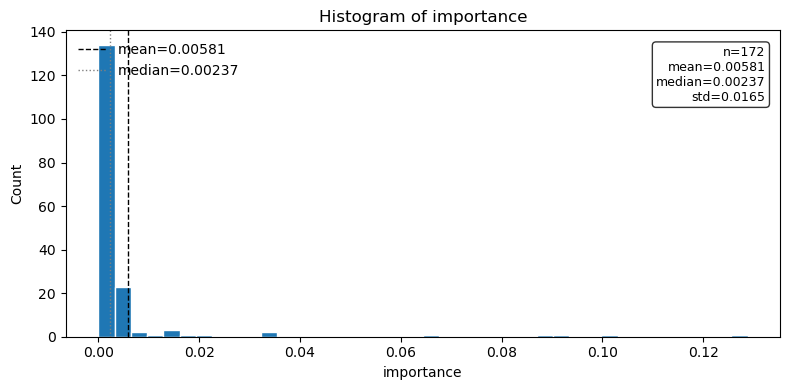

<Axes: title={'center': 'Histogram of importance'}, xlabel='importance', ylabel='Count'>

In [17]:
RandomForestDiscovery.plot_feature_importance_histogram(feature_importance_df, "importance", bins=40, kde=False, annotate_stats=True)

### Select Top Features and Create Scatter Plot

In [18]:
# Add to feature_name to top_feature_counts_df
feature_importance_df['feature_standard_name'] = feature_importance_df["feature"].apply(lambda x: x.split("__")[0] if "__" in x else x)

# sort by importance to see top features
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(20)

,target_col,feature,importance,feature_standard_name
108,vulnerability_indicator,x_log_signed_con_primary_energy_twh__slope,0.128778,x_log_signed_con_primary_energy_twh
107,vulnerability_indicator,x_log_signed_con_primary_energy_twh__delta,0.101454,x_log_signed_con_primary_energy_twh
105,vulnerability_indicator,x_log_signed_con_primary_energy_twh__max,0.091250,x_log_signed_con_primary_energy_twh
106,vulnerability_indicator,x_log_signed_con_primary_energy_twh__last,0.088528,x_log_signed_con_primary_energy_twh
102,vulnerability_indicator,x_log_signed_con_primary_energy_twh__mean,0.064964,x_log_signed_con_primary_energy_twh
104,vulnerability_indicator,x_log_signed_con_primary_energy_twh__min,0.034631,x_log_signed_con_primary_energy_twh
103,vulnerability_indicator,x_log_signed_con_primary_energy_twh__std,0.032581,x_log_signed_con_primary_energy_twh
143,vulnerability_indicator,x_log_signed_con_demand_per_capita__slope,0.020480,x_log_signed_con_demand_per_capita
141,vulnerability_indicator,x_log_signed_con_demand_per_capita__last,0.016790,x_log_signed_con_demand_per_capita
138,vulnerability_indicator,x_log_signed_con_demand_per_capita__std,0.015153,x_log_signed_con_demand_per_capita


In [19]:
feature_importance_df.to_clipboard(index=False)

In [20]:
selected_features = rf_discovery.select_top_features(
    feature_importance_df,
    feature_standard_name_col="feature_standard_name",
    top_k=2,
)
print("Selected features for scenario discovery:", selected_features)

Selected features for scenario discovery: ['x_log_signed_con_primary_energy_twh', 'x_log_signed_con_demand_per_capita']


In [21]:
selected_features = selected_features + ["cap_govt_effectiveness"]

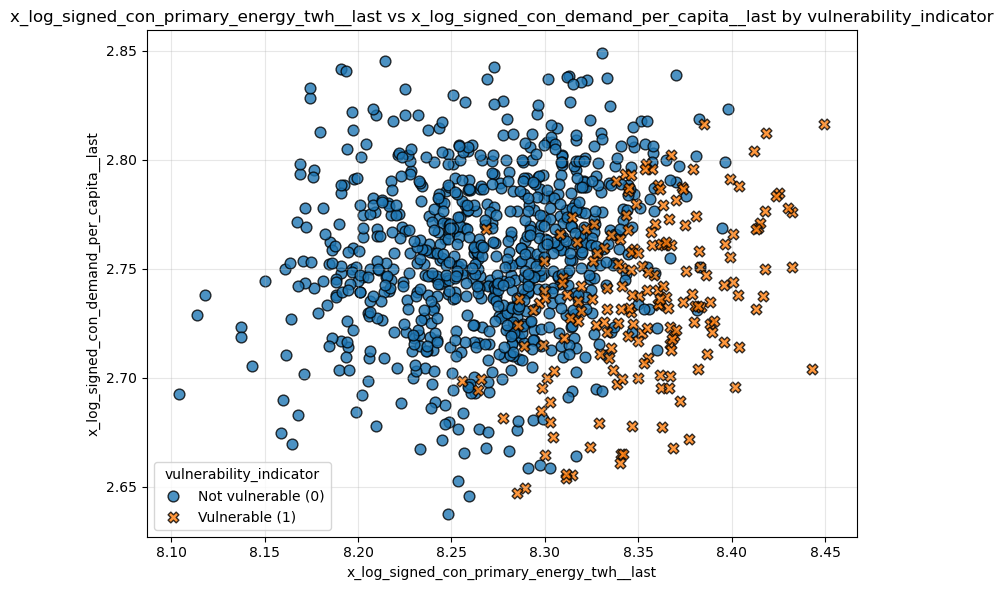

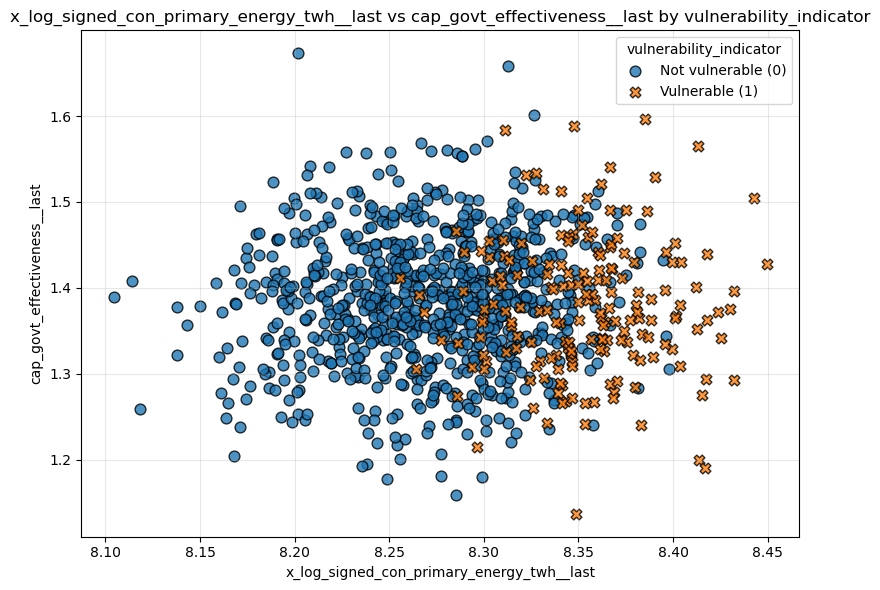

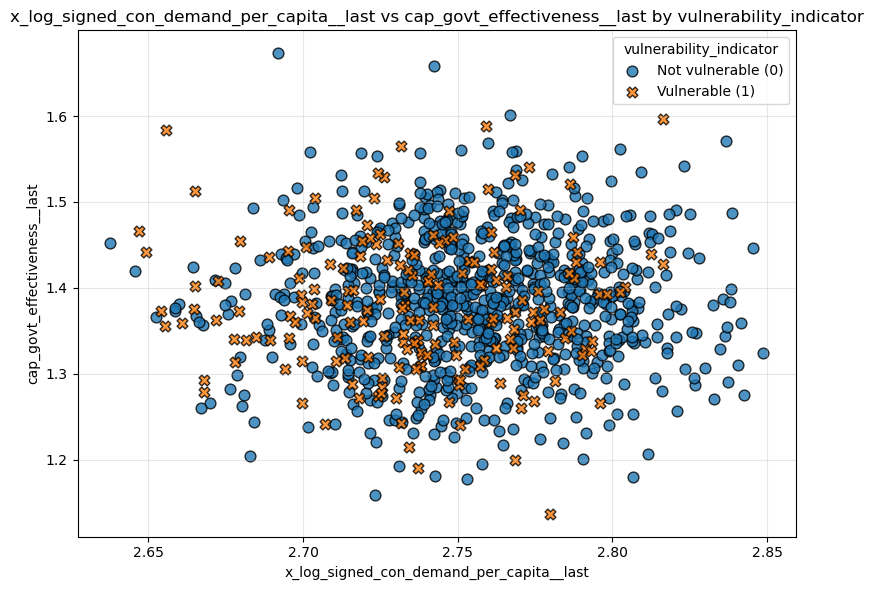

In [22]:
# Pairwise scatter plots for the selected features
for x_feat, y_feat in combinations(selected_features, 2):
    VulnerabilityAnalyzer.plot_xy_by_vulnerability(
        merged_df,
        x=x_feat + "__last",
        y=y_feat + "__last",
        vuln_col="vulnerability_indicator",
    )

### Optimization


In [23]:
# Optimization utilities are now provided by ScenarioDiscoveryOptimizer.


In [24]:
optimizer = ScenarioDiscoveryOptimizer(
    lower=0.1,
    upper=0.9,
    popsize=200,
    generations=200,
    seed=55555,
)


In [25]:
pt, optimization_results, cmp_selected = optimizer.optimize(
    merged_df,
    selected_features,
    vuln_col="vulnerability_indicator",
)

if "POST_PROCESSING_DIR_PATH" in globals():
    optimization_results.to_csv(
        os.path.join(POST_PROCESSING_DIR_PATH, "sd_optimization_results.csv"),
        index=False,
    )

optimization_results.head()


,x_log_signed_con_primary_energy_twh__last,x_log_signed_con_demand_per_capita__last,cap_govt_effectiveness__last,coverage,density,x_log_signed_con_primary_energy_twh__last__cutoff,x_log_signed_con_demand_per_capita__last__cutoff,cap_govt_effectiveness__last__cutoff,comparators
0,0.320997,0.885657,0.880613,0.885246,0.310345,8.255884,2.798715,1.473685,"[>, <, <]"
1,0.320984,0.885327,0.880393,0.885246,0.310345,8.255882,2.798638,1.473515,"[>, <, <]"
2,0.320984,0.884824,0.880350,0.885246,0.310345,8.255882,2.798519,1.473482,"[>, <, <]"
3,0.372485,0.884233,0.880102,0.879781,0.334719,8.264282,2.798354,1.473291,"[>, <, <]"
4,0.372485,0.884455,0.880102,0.879781,0.334719,8.264282,2.798416,1.473291,"[>, <, <]"


In [26]:
optimization_results.head()


,x_log_signed_con_primary_energy_twh__last,x_log_signed_con_demand_per_capita__last,cap_govt_effectiveness__last,coverage,density,x_log_signed_con_primary_energy_twh__last__cutoff,x_log_signed_con_demand_per_capita__last__cutoff,cap_govt_effectiveness__last__cutoff,comparators
0,0.320997,0.885657,0.880613,0.885246,0.310345,8.255884,2.798715,1.473685,"[>, <, <]"
1,0.320984,0.885327,0.880393,0.885246,0.310345,8.255882,2.798638,1.473515,"[>, <, <]"
2,0.320984,0.884824,0.880350,0.885246,0.310345,8.255882,2.798519,1.473482,"[>, <, <]"
3,0.372485,0.884233,0.880102,0.879781,0.334719,8.264282,2.798354,1.473291,"[>, <, <]"
4,0.372485,0.884455,0.880102,0.879781,0.334719,8.264282,2.798416,1.473291,"[>, <, <]"


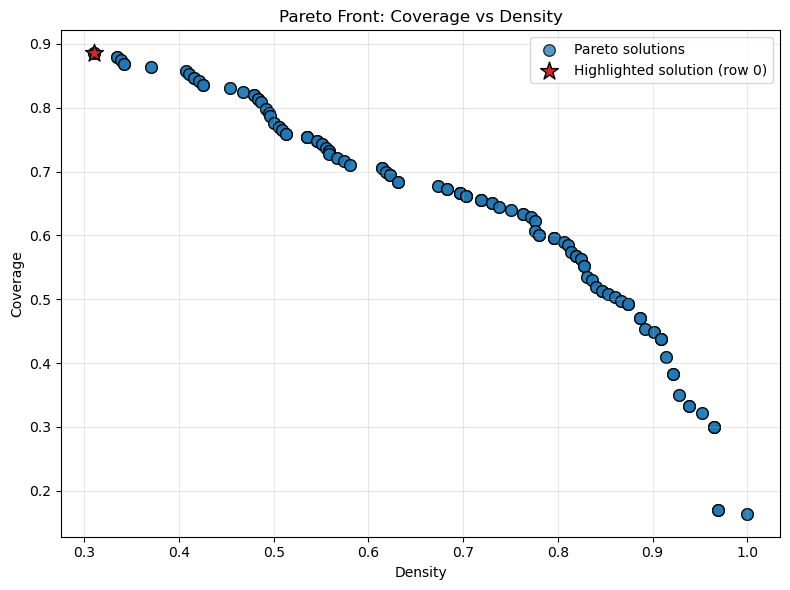

<Axes: title={'center': 'Pareto Front: Coverage vs Density'}, xlabel='Density', ylabel='Coverage'>

In [27]:
ScenarioDiscoveryOptimizer.plot_pareto_front(optimization_results, annotate=False)


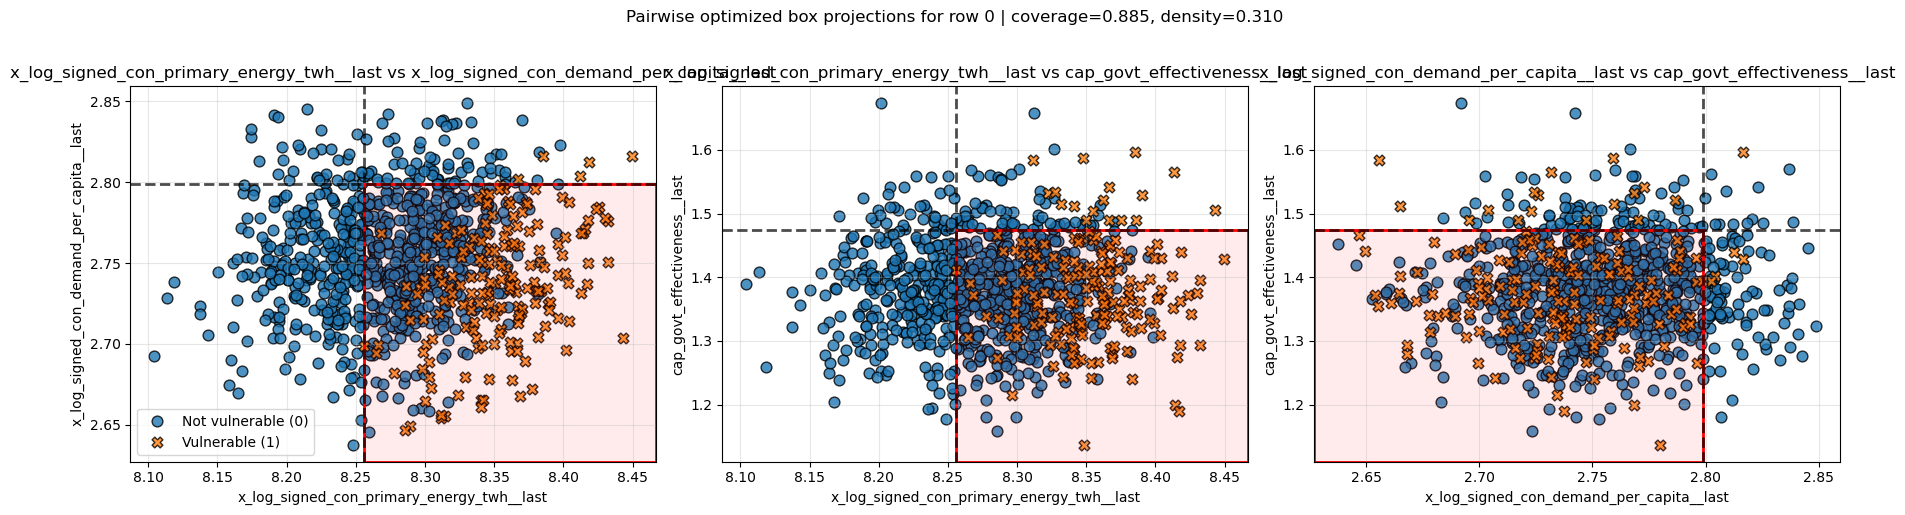

{'row_idx': 0,
 'mode': 'pairwise',
 'driver_cols': ['x_log_signed_con_primary_energy_twh__last',
  'x_log_signed_con_demand_per_capita__last',
  'cap_govt_effectiveness__last'],
 'pairs': [{'x_col': 'x_log_signed_con_primary_energy_twh__last',
   'y_col': 'x_log_signed_con_demand_per_capita__last',
   'cutoff_x': 8.255883510343008,
   'cutoff_y': 2.7987154509736283,
   'comparators': {'x_log_signed_con_primary_energy_twh__last': '>',
    'x_log_signed_con_demand_per_capita__last': '<'}},
  {'x_col': 'x_log_signed_con_primary_energy_twh__last',
   'y_col': 'cap_govt_effectiveness__last',
   'cutoff_x': 8.255883510343008,
   'cutoff_y': 1.4736846758245556,
   'comparators': {'x_log_signed_con_primary_energy_twh__last': '>',
    'cap_govt_effectiveness__last': '<'}},
  {'x_col': 'x_log_signed_con_demand_per_capita__last',
   'y_col': 'cap_govt_effectiveness__last',
   'cutoff_x': 2.7987154509736283,
   'cutoff_y': 1.4736846758245556,
   'comparators': {'x_log_signed_con_demand_per_capita

In [28]:
ScenarioDiscoveryOptimizer.plot_boxed_scatter_from_optimization_result(
    pt,
    optimization_results,
    row_idx=0,
)
